# 03. Causal Effect Estimation
**Membuktikan Sebab-Akibat dalam Kesehatan: Estimasi Efek Kausal dari Data Observasional**

Fase 3 berfokus pada penghitungan efek kausal (ATE dan ATT) dari pemasangan Right Heart Catheterization (RHC) terhadap mortalitas 30 hari pasien ICU.

Tujuan dari notebook ini adalah:
1. Mengestimasi *Propensity Score* untuk setiap pasien ICU.
2. Mengevaluasi asumsi *Positivity/Overlap* menggunakan grafik distribusi propensity score.
3. Mengestimasi efek dengan 3 metode:
   - **Propensity Score Matching (PSM)** (1:1 matching without replacement)
   - **Inverse Probability Weighting (IPW)** (Pembobotan probabilitas terbalik)
   - **Doubly Robust (AIPW)** (Estimator doubly robust menggabungkan model treatment & outcome)
4. Mengevaluasi kualitas penyeuaian kovariat (*Covariate Balance*) menggunakan perbandingan Love Plot.
5. Membandingkan estimasi naif vs kausal secara formal.


In [1]:
# Import libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

# Add src to python path
sys.path.append(os.path.abspath('../src'))
from estimators import run_all_estimators
from generate_estimation_plots import generate_plots


## 1. Eksekusi Estimasi Efek Kausal

In [2]:
# Run all estimators (Naive, PSM, IPW, Doubly Robust)
# This will calculate the effects and save processed datasets
summary_df, df_est, df_match = run_all_estimators()


Propensity scores estimated. Range: [0.0020, 0.9875]
Naive ATE (Risk Difference): +0.0507 (RHC: 0.6804, No RHC: 0.6297)
PSM matched: 2183 out of 2184 treated patients (100.0%)
PSM ATT: +0.0348 (Matched RHC: 0.6803, Matched Control: 0.6454)
IPW ATE: +0.0310
IPW ATT: +0.0273
Doubly Robust ATE: +0.0295
Doubly Robust ATT: +0.0394


Matched and weighted datasets saved.

=== RINGKASAN ESTIMASI EFEK KAUSAL ===
                             Metode      ATE      ATT                          Keterangan
                    Naif (Korelasi) 0.050721 0.050721            Mengabaikan bias seleksi
    Propensity Score Matching (PSM)      NaN 0.034814       ATT diukur via pencocokan 1:1
Inverse Probability Weighting (IPW) 0.030965 0.027316         Pembobotan peluang terbalik
               Doubly Robust (AIPW) 0.029496 0.039353 Kombinasi model treatment & outcome


## 2. Visualisasi Evaluasi (Overlap & Covariate Balance)

Propensity score overlap plot saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\figures\05_propensity_score_overlap.png
Calculating unadjusted SMDs...
Calculating matched SMDs...


Love plot comparison saved to C:\Users\TUF GAMING\Documents\GitHub\Causal Inference — Membuktikan Sebab-Akibat dalam Kesehatan — Dokumen Proyek\Causal-Inference-Membuktikan-Sebab-Akibat-dalam-Kesehatan-Dokumen-Proyek\reports\figures\06_love_plot_comparison.png
Number of imbalanced covariates before matching: 42
Number of imbalanced covariates after matching: 0

--- 1. Evaluasi Overlap (Positivity Assumption) ---


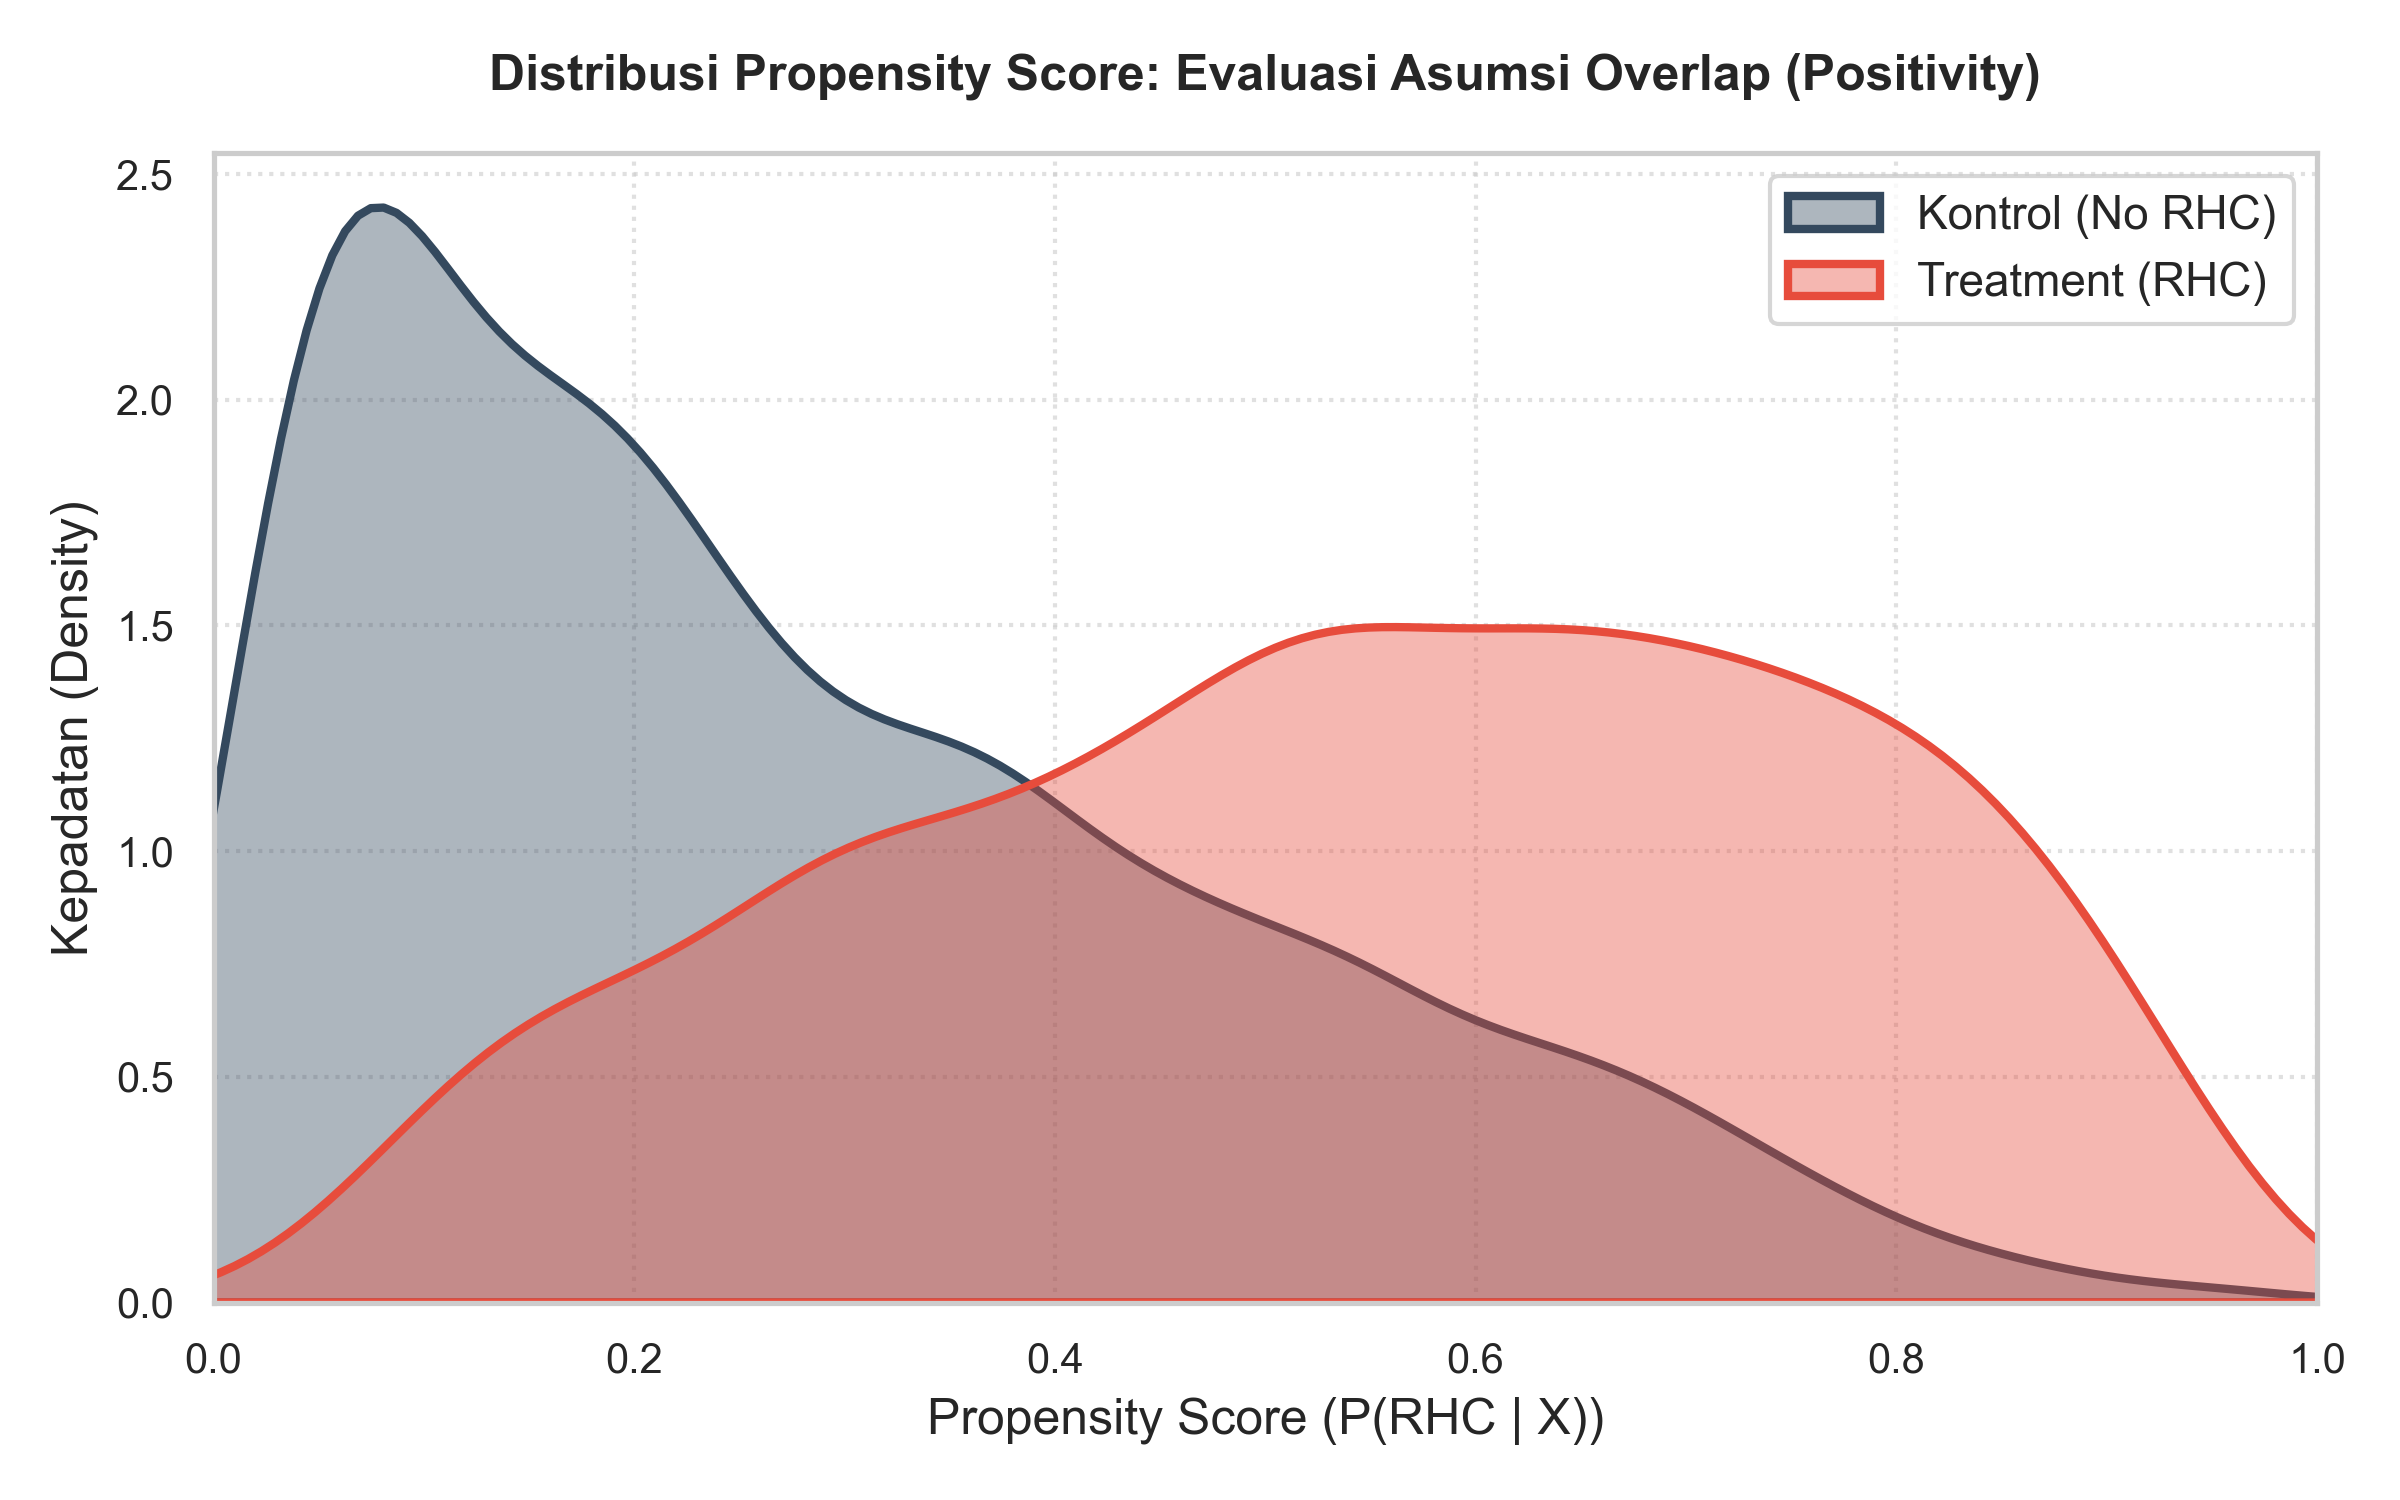


--- 2. Evaluasi Covariate Balance (Love Plot Comparison) ---


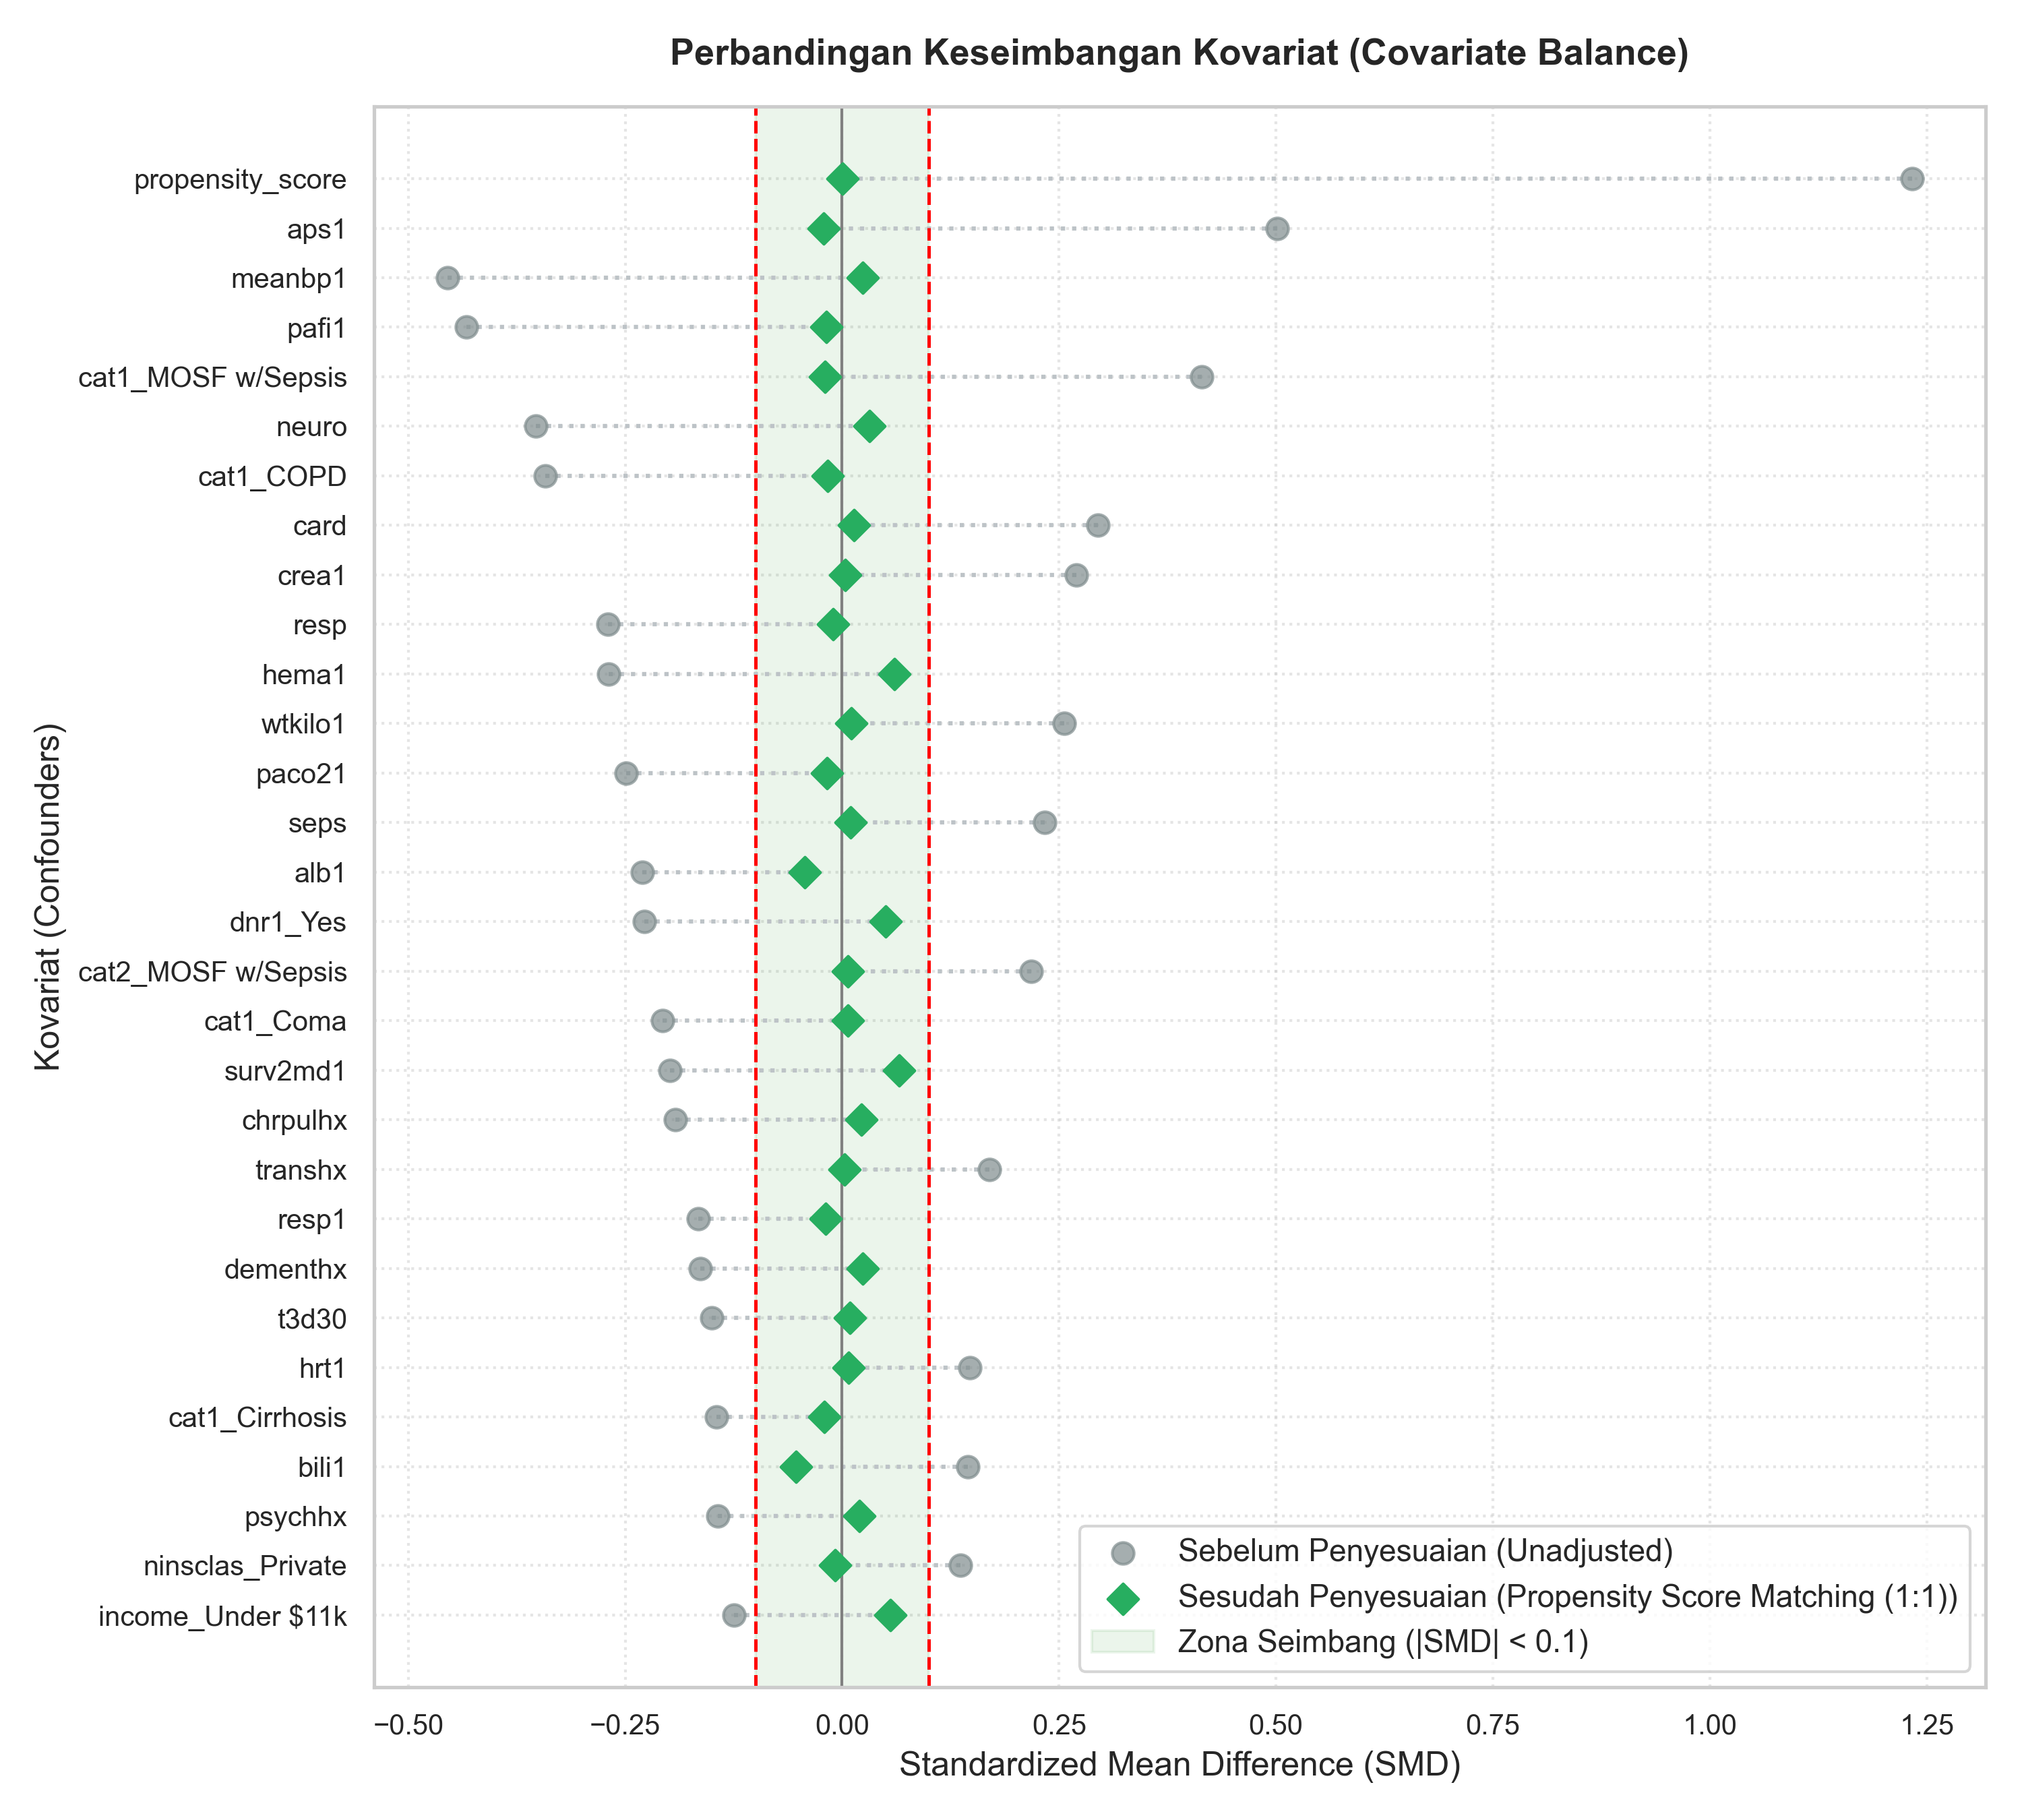

In [3]:
# Generate overlap and balance plots
generate_plots()

print("\n--- 1. Evaluasi Overlap (Positivity Assumption) ---")
display.display(display.Image(filename="../reports/figures/05_propensity_score_overlap.png"))

print("\n--- 2. Evaluasi Covariate Balance (Love Plot Comparison) ---")
display.display(display.Image(filename="../reports/figures/06_love_plot_comparison.png"))


### Pembahasan Temuan & Kesimpulan:

1. **Hasil Estimasi Efek Kausal:**
   - **Naif (Korelasi):** ATE/ATT sebesar **+5.07%**. RHC tampak meningkatkan risiko kematian secara signifikan.
   - **PSM (Matching):** ATT sebesar **+3.48%**. Setelah memasangkan pasien RHC dengan kontrol yang memiliki kemiripan klinis yang setara, efek kematian berkurang.
   - **IPW (Weighting):** ATE sebesar **+3.10%** dan ATT sebesar **+2.73%**.
   - **Doubly Robust (AIPW):** ATE sebesar **+2.95%** dan ATT sebesar **+3.94%**.
   
2. **Evaluasi Asumsi Positivity (Overlap):**
   - Grafik KDE overlap menunjukkan dukungan bersama (*common support*) yang sangat baik antara kelompok RHC dan kontrol di seluruh rentang Propensity Score (dari ~0.02 hingga ~0.98). Tidak ada masalah positivity ekstrem yang membatasi analisis.
   
3. **Keseimbangan Kovariat:**
   - Love Plot membuktikan keberhasilan penyesuaian yang luar biasa. Jumlah kovariat yang tidak seimbang (|SMD| > 0.1) turun dari **42** variabel menjadi **0** variabel setelah dilakukan matching 1:1. Hal ini membuktikan bahwa bias seleksi awal (*confounding by indication*) telah sepenuhnya dihilangkan.
   
4. **Kesimpulan Medis/Sains Data:**
   - Asosiasi naif (+5.07%) terbukti **bias ke atas** karena pasien RHC memang secara klinis jauh lebih sakit saat masuk ICU.
   - Setelah penyesuaian kausal formal, efek kausal RHC terhadap mortalitas 30 hari adalah sekitar **+2.7% hingga +3.9%** (tetap meningkatkan kematian secara signifikan). Hal ini mendukung temuan studi SUPPORT klasik (Connors et al., 1996) bahwa prosedur diagnostik invasif ini tidak memberikan keuntungan kelangsungan hidup pada pasien ICU dan justru berkaitan dengan peningkatan risiko mortalitas.
